# Tarea 01: Aproximación de una función desconocida

Generamos datos con una función que **nosotros definimos y ustedes no conocen**. Su
trabajo es reconstruirla a partir de los datos.

No es un acertijo: es lo que hace el machine learning todos los días. El capítulo 02
plantea el aprendizaje como **aproximación de funciones**, y aquí van a hacer
exactamente eso, con la ventaja rara de que existe una respuesta correcta y un límite
teórico al que se puede llegar.

## Lo que hay

- `train.csv`: 800 observaciones con 12 variables (`x1` a `x12`) y la respuesta `y`.
- `test.csv`: 400 observaciones con las mismas 12 variables, **sin** `y`.

Entregan sus 400 predicciones y un bot las califica automáticamente.

## Cómo se califica

| Su MSE en el conjunto de prueba | Calificación |
|---|---|
| Igual o peor que una regresión lineal con las 12 variables crudas | **5.0** |
| Igual al modelo bien especificado (el error irreducible) | **10.0** |
| En medio | proporcional a la mejora |

**El 5 está garantizado si entregan algo que corre.** El código del baseline se lo damos
hecho más abajo; de ahí para arriba es mérito suyo.

Tienen **3 intentos** de calificación. Un comentario `/validar` revisa el formato y les
dice cuál es su MSE objetivo **sin gastar intento**, así que úsenlo antes del primero.

## Qué se evalúa además del MSE

El MSE es la mitad. La otra mitad es la **Parte 5: la bitácora**, donde documentan cada
hipótesis que probaron — incluidas las que fallaron. Un notebook con buen MSE y bitácora
vacía vale poco: significa que no entendieron por qué funcionó.

---

## Las reglas sobre la IA

**Sí pueden usar IA. De hecho quiero que la usen.** Pero de una forma específica.

La IA no puede ver sus datos. Puede explicarles teoría, listarles técnicas o decirles qué
función de `matplotlib` usar. Lo que **no** puede hacer es mirar una gráfica de residuales
y decirles qué término falta, porque eso solo lo revela correr el código con *sus* datos, y
cada quien tiene datos distintos.

Así que la IA es su tutor, no su chofer. Para que sea tutor, péguenle esto al inicio de
cada conversación:

> Eres mi tutor de regresión, no mi resolvedor. Reglas: (1) no escribes código que yo
> pueda copiar; si te pido código, me devuelves el nombre de la función y su docstring.
> (2) No me das la respuesta: me preguntas qué espero ver y por qué. (3) Cuando me
> equivoque, no me corriges: me sugieres qué gráfica revelaría mi error. (4) Máximo
> tres oraciones por respuesta.

Y una regla para ustedes: **si la IA les da código y no pueden explicar qué hace línea
por línea, bórrenlo y escríbanlo ustedes.** Se nota en la bitácora, y se nota más en el
examen.

---
## Parte 0. Su variante

Cada quien tiene **datos distintos**: las 12 variables juegan papeles diferentes según
la persona. Copiar las predicciones de alguien más da un MSE malísimo. Comparar
*métodos* entre ustedes, en cambio, es buena idea y se los recomiendo.

Su carpeta de datos se identifica con su **clave única del ITAM**.

In [23]:
import hashlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 110
SEMILLA = 42

In [24]:
# TODO: pongan su clave única del ITAM (con o sin ceros a la izquierda, da lo mismo)
CLAVE_UNICA = "207725"

# De la clave sale el nombre de su carpeta. No lo cambien a mano.
_clave = "".join(c for c in CLAVE_UNICA if c.isdigit()).zfill(9)
CARPETA = "v" + hashlib.sha256(_clave.encode()).hexdigest()[:8]

# Funciona corriendo el notebook desde `tareas/` o desde la raíz del repo
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "tareas/tarea_01_datos").exists())
MIS_DATOS = RAIZ / "tareas/tarea_01_datos" / CARPETA

assert CLAVE_UNICA, "207725"
assert MIS_DATOS.exists(), (
    f"No existe la carpeta {CARPETA}. Revisen su clave única: si está mal escrita, "
    f"el nombre de la carpeta sale distinto y no van a encontrar sus datos."
)

train = pd.read_csv(MIS_DATOS / "train.csv")
test = pd.read_csv(MIS_DATOS / "test.csv")

VARIABLES = [f"x{i}" for i in range(1, 13)]
print(f"Su variante: {CARPETA}")
print(f"train: {train.shape}   test: {test.shape}")
train.head()

Su variante: v8eb0645a
train: (800, 13)   test: (400, 12)


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,y
0,17.714626,0.114204,-1.094570,-1.674187,0.421955,-0.901019,87.990590,2.730300,-0.397400,1.835396,-1.877390,-0.313455,6.616719
1,1.604832,-0.234925,2.151211,-1.302902,1.119646,1.263380,21.177401,0.809584,0.145037,-0.292356,1.353777,0.399385,-1.711183
2,2.353956,-0.948751,-2.696048,0.488483,0.954342,-0.535690,68.169841,3.227908,-0.177283,-1.396302,2.393848,-0.181742,34.475875
3,1.492629,-0.222766,-2.196672,1.791764,0.369471,1.986220,75.639736,1.099123,-0.290573,-0.340280,0.906264,-0.315103,32.474530
4,0.727872,-0.357165,-1.177114,0.537061,2.026939,0.540531,25.126134,3.085493,0.160244,1.585811,-0.195615,0.088959,15.220861


In [25]:
# TODO: primer vistazo. ¿Qué rangos tienen las variables? ¿Hay faltantes?
train.describe().T


,count,mean,std,min,25%,50%,75%,max
x1,800.0,1.609604,2.276457,0.051758,0.501122,0.999641,1.782477,26.875679
x2,800.0,-0.010384,1.014777,-3.083424,-0.765855,0.012169,0.658048,3.152846
x3,800.0,0.004399,1.752120,-2.995587,-1.527673,0.034247,1.538089,2.995127
x4,800.0,-0.084484,1.188499,-1.995361,-1.160160,-0.103082,0.944524,1.994521
x5,800.0,1.594626,1.744346,0.043603,0.499084,1.002867,2.056138,12.783580
x6,800.0,-0.038603,0.957765,-2.396385,-0.719192,-0.042644,0.648568,2.767809
x7,800.0,49.081056,29.612532,0.007483,22.888083,48.176813,75.357600,99.962168
x8,800.0,1.930864,1.144543,0.010516,0.887206,1.931778,2.879606,3.998821
x9,800.0,0.004363,0.293893,-0.497851,-0.259829,0.004152,0.261394,0.492580
x10,800.0,0.047771,1.176625,-1.993682,-1.006413,0.044152,1.089071,1.999257


### 0.1 El baseline que hay que ganar

Este es el modelo de referencia: una regresión lineal con las 12 variables **tal como
vienen**, sin transformar nada. Su MSE sobre el conjunto de prueba es, por definición, la
calificación **5.0**.

Se lo damos corrido para que arranquen sabiendo exactamente qué hay que superar.

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


X_train, X_val, y_train, y_val = train_test_split(
    train[VARIABLES], train["y"], test_size=0.25, random_state=SEMILLA
)

baseline = LinearRegression().fit(X_train, y_train)
mse_baseline = mean_squared_error(y_val, baseline.predict(X_val))

print(f"MSE del baseline en validación: {mse_baseline:.2f}")
print(f"R² del baseline en validación : {baseline.score(X_val, y_val):.3f}")
print(f"\nDesviación estándar de y: {train['y'].std():.2f}")



MSE del baseline en validación: 116.85
R² del baseline en validación : 0.421

Desviación estándar de y: 13.67


### 0.2 Cómo medir su progreso sin gastar intentos

Solo tienen 3 calificaciones, y necesitan medirse muchas más veces que eso. La solución
es la de siempre: **partir `train` en entrenamiento y validación**, ajustar en una parte
y medir en la otra. Eso ya lo hicimos en la celda anterior.

Dos advertencias importantes:

- Su MSE de validación **no** va a coincidir exactamente con el oficial. El oficial se
  mide sobre `test.csv`, que son otras 400 observaciones. Su número es una *estimación*
  del oficial, con su propia incertidumbre.
- Si eligen entre muchos modelos usando el mismo conjunto de validación, van a
  sobreajustar la validación. Para decisiones finas, usen validación cruzada
  (`cross_val_score`) en lugar de una sola partición.

**Nunca** ajusten nada usando `test.csv`: no tiene `y`, así que ni podrían — y ese es
justo el punto.

---
## Parte 1. Exploración

Antes de modelar, mírenlos. El objetivo de esta parte **no** es encontrar la respuesta,
es formarse sospechas que después van a confirmar o descartar.

Tres cosas que vale la pena graficar:

1. La distribución de cada variable por separado.
2. `y` contra cada variable, una gráfica por variable.
3. La matriz de correlación.

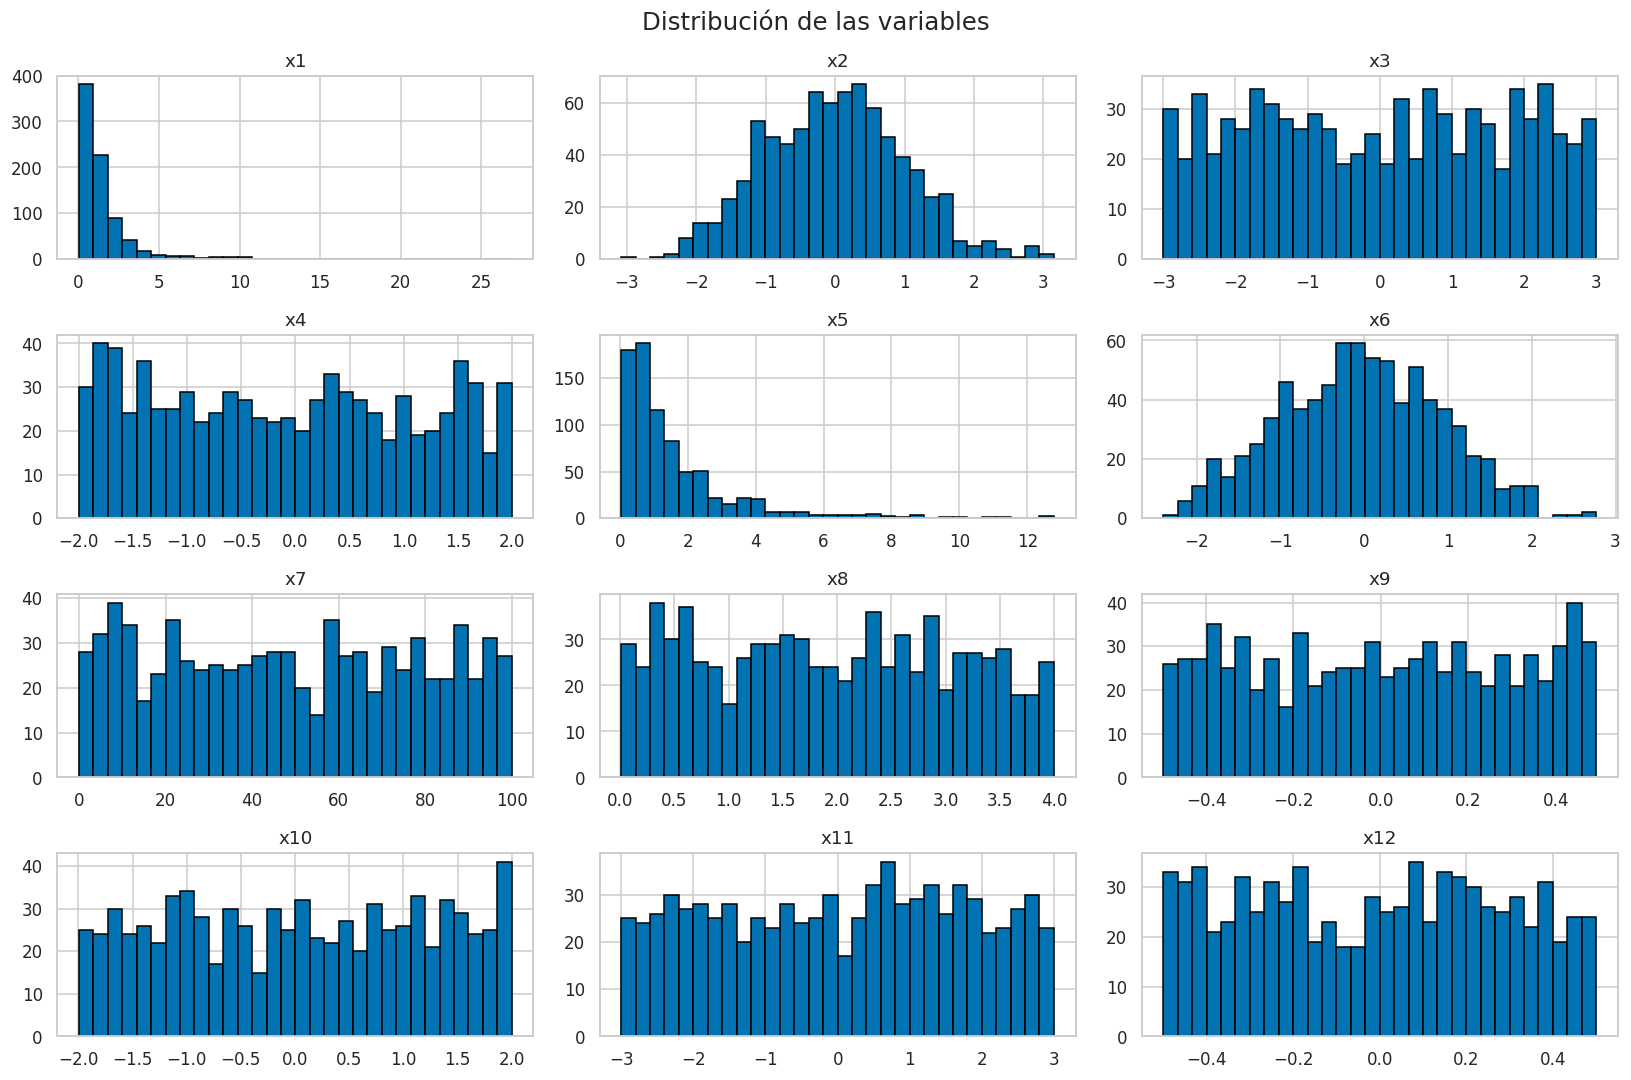

In [27]:
# TODO: distribución de cada una de las 12 variables.
# Pista de método: `train[VARIABLES].hist(...)` hace las 12 de un golpe.

import matplotlib.pyplot as plt

train[VARIABLES].hist(
figsize=(15,10),
bins=30,
edgecolor="black"
)

plt.suptitle("Distribución de las variables", fontsize=16)
plt.tight_layout()
plt.show()

#Hice un histograma de cada variable para ver cómo se reparten sus valores. 
# x1 y x5 tienen casi todos sus datos por debajo de 3, pero unos pocos muy grandes (x1 llega hasta 26.9 y x5 hasta 12.8). 
# Por eso pensé que un log podría ayudar en esas dos. 
# x2 y x6 parecen una campana centrada en 0. Otras, como x3, x4, x7, x8, x9, x10, x11 y x12, están repartidas parejo entre su mínimo y su máximo. x7 va de 0 a 100, mucho más grande que las demás, y x9 y x12 solo van de -0.4 a 0.4.
#las variables tienen escalas muy distintas, x7 va de 0 a 100, x8 de 0 a 4, y x9 y x12 solo de -0.5 a 0.5.

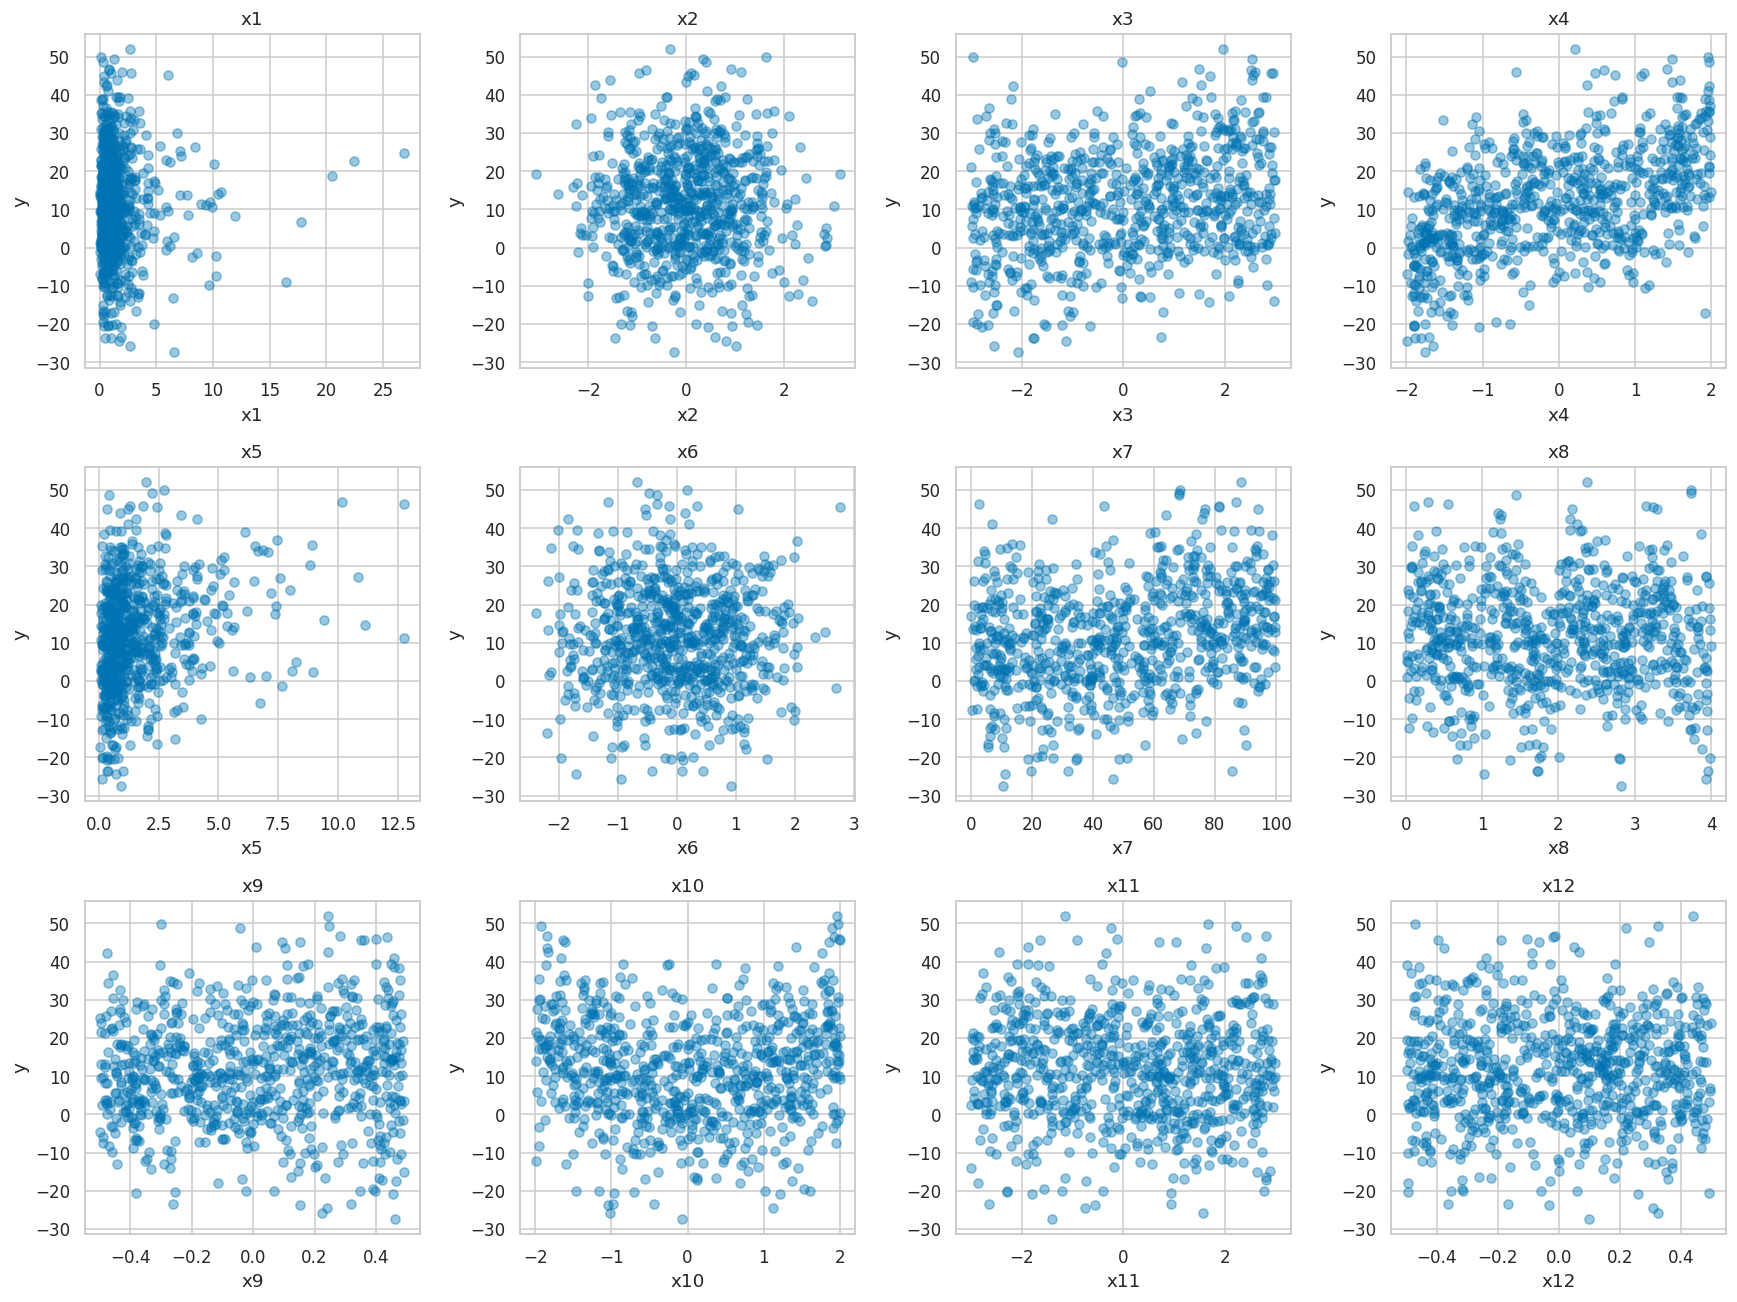

In [28]:
# TODO: `y` contra cada variable. Una rejilla de 12 paneles.
# Usen puntos con transparencia (`alpha`): con 800 observaciones se traslapan.
import matplotlib.pyplot as plt
fig, axes = plt.subplots(
    3, 4,
    figsize=(16,12)
)

axes = axes.flatten()

for i, col in enumerate(VARIABLES):
    axes[i].scatter(
    train[col],
    train["y"],
    alpha=0.4
    )   

    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("y")

plt.tight_layout()
plt.show()

#Hice una rejilla de 12 gráficas con "y" contra cada variable, con puntos azules de diferente tonos para cada una.
# La más clara fue x4, que sube en línea recta: a mayor x4, mayor y. x3 y x7 también suben un poco. 
# En x5 vi que y sube rápido con los valores chicos y luego se aplana, lo que me hizo pensar en un log. 
# En x10 me pareció ver valores más altos de y en los extremos, como una U suave, lo que me hizo pensar en x10². 
# x1 tiene casi todos los puntos cerca de 0 y unos pocos muy lejos. 
# Las demás (x2, x6, x9, x11, x12) se ven como una nube sin forma. 
# Con estas gráficas no pude ver la interacción entre x3 y x9, porque solo muestran una variable a la vez.

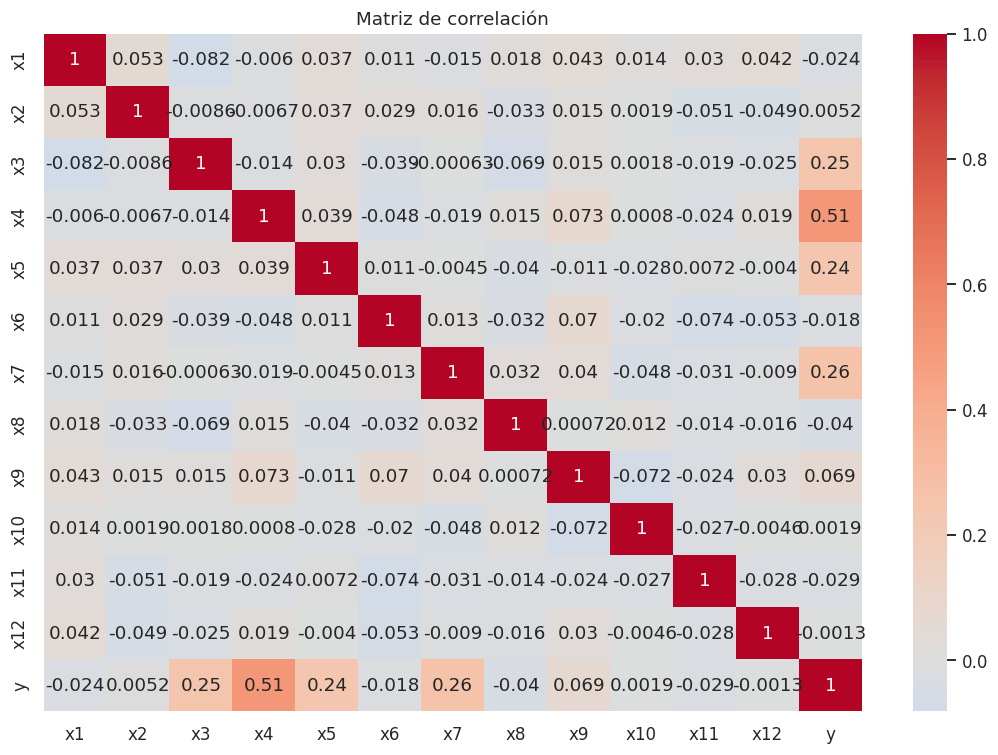

y      1.000000
x4     0.506774
x7     0.260701
x3     0.247259
x5     0.238162
x9     0.068934
x8    -0.039583
x11   -0.029329
x1    -0.024000
x6    -0.018243
x2     0.005236
x10    0.001891
x12   -0.001271
Name: y, dtype: float64

In [29]:
# TODO: matriz de correlación entre las 12 variables y `y`.

import seaborn as sns

corr = train.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
corr,
annot=True,
cmap="coolwarm",
center=0
)

plt.title("Matriz de correlación")
plt.show()

corr_y=corr["y"].sort_values(key=abs, ascending=False)
corr_y  #para saber que variables estan mas relacionadas con y

#Calculé la correlación de cada variable con y. Las más relacionadas fueron x4 (0.51), x7 (0.26), x3 (0.25) y x5 (0.24). 
# x10 tiene correlación casi cero con y (0.002), y aun así x10² resultó ser el término que más bajó el error, unos 22 puntos. 
# Esto me enseñó que la correlación solo detecta relaciones en línea recta, y que una variable puede ser muy importante aunque su correlación sea cero.

### 1.1 Registren sus sospechas ahora

Llenen esta tabla **antes** de seguir. Va a ser incómoda de llenar y eso es intencional:
la parte que enseña es volver a leerla al final y ver en qué se equivocaron.

| Variable | ¿Qué sospecho? | ¿En qué gráfica lo vi? | ¿Qué tan seguro estoy? |
|---|---|---|---|
| `x1` | | | |
| `x2` | | | |
| `x3` | | | |
| `x4` | | | |
| `x5` | | | |
| `x6` | | | |
| `x7` | | | |
| `x8` | | | |
| `x9` | | | |
| `x10` | | | |
| `x11` | | | |
| `x12` | | | |

---
## Parte 2. La escalera de residuales

Este es el método central de la tarea, y el que quiero que se lleven de por vida.

Un **residual** es lo que su modelo no logró explicar: `residual = y - ŷ`. Si su modelo
capturó todo lo que había, los residuales deben ser **ruido**: sin forma, sin patrón, sin
estructura. Si al graficar los residuales contra una variable se ve una *forma*, esa
forma es un pedazo de la función que les falta — y la forma les dice qué término agregar.

El ciclo es siempre el mismo:

1. Ajustan el modelo que tienen.
2. Grafican los residuales contra **cada** variable.
3. Si alguna gráfica tiene forma, agregan un término que capture esa forma.
4. Vuelven al paso 1.

Paran cuando ya ninguna gráfica tiene forma, o cuando el MSE deja de bajar.

### ¿Y qué término agrego?

Eso es exactamente lo que tienen que descubrir, y es el trabajo de la tarea.

Lo que sí les conviene es pedirle a su IA el **catálogo**: "¿qué transformaciones existen
para linealizar una relación no lineal?", "¿cómo se modela un efecto que cambia de golpe
a partir de cierto valor?". Eso es conocimiento general y la IA lo tiene completo.

Cuál de esas transformaciones aplica, a cuál de sus doce variables y con qué parámetro,
no se lo puede decir nadie: solo su gráfica. Ahí es donde se aprende.

In [30]:
def ajusta(columnas_extra=None):
    """Ajusta una lineal con las 12 crudas más las columnas derivadas que le pasen.

    `columnas_extra` es un dict {nombre: función que recibe un DataFrame y devuelve
    una Serie}. Así el mismo término se construye igual en train, validación y test,
    que es donde se equivoca todo el mundo.

    Devuelve (modelo, mse_validacion, residuales_de_validacion, constructor).
    """
    columnas_extra = columnas_extra or {}

    def construye(df):
        salida = df[VARIABLES].copy()
        for nombre, f in columnas_extra.items():
            salida[nombre] = f(df)
        return salida

    modelo = LinearRegression().fit(construye(X_train), y_train)
    pred_val = modelo.predict(construye(X_val))
    mse = mean_squared_error(y_val, pred_val)
    return modelo, mse, y_val - pred_val, construye


modelo, mse, residuales, _ = ajusta()
print(f"Modelo con las 12 crudas -> MSE de validación {mse:.2f}")

Modelo con las 12 crudas -> MSE de validación 116.85


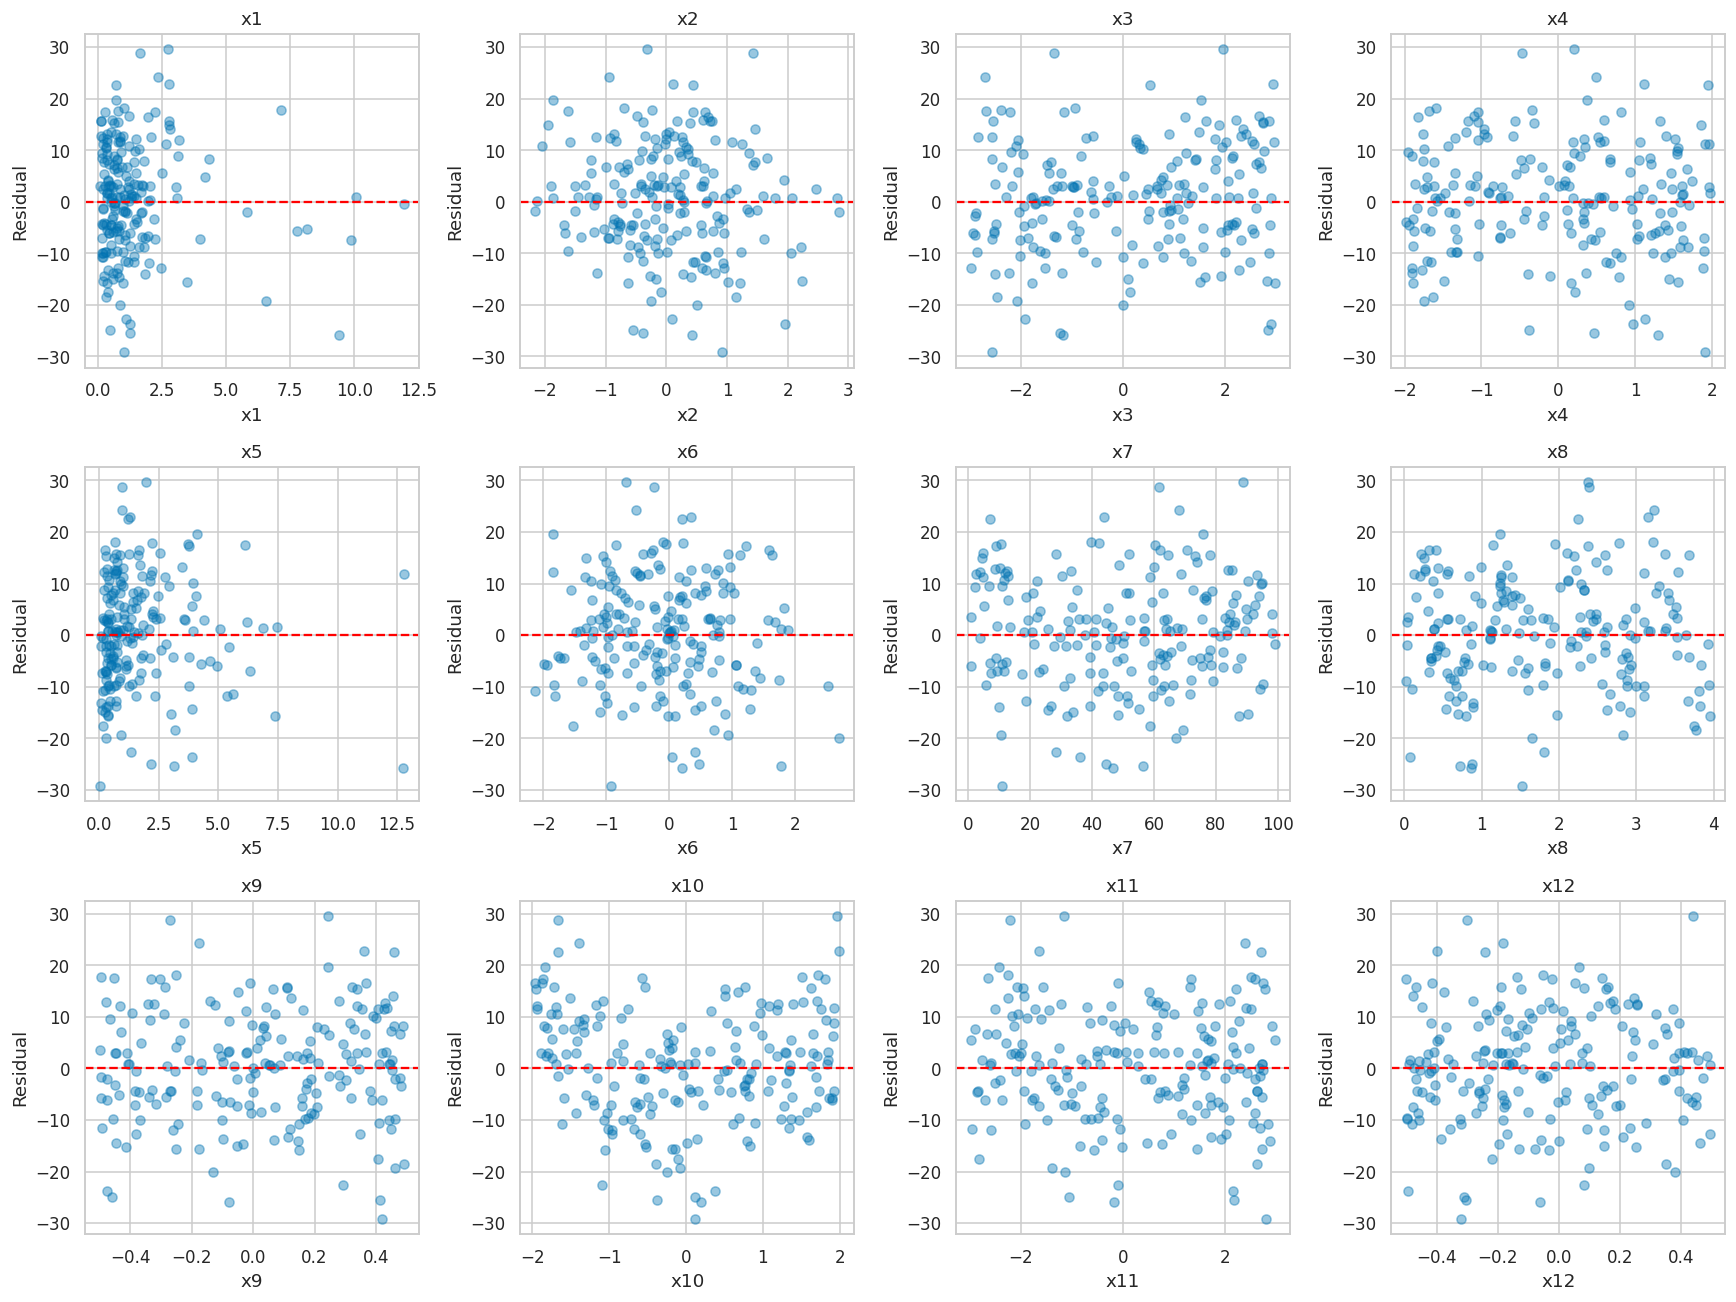

In [31]:
# TODO: grafiquen los residuales contra cada una de las 12 variables.
# Una rejilla de 12 paneles, y en cada uno una línea horizontal en 0 como referencia.
#
# Lo que buscan es FORMA, no dispersión. Una nube gruesa sin patrón está bien;
# una nube que sube, baja, ondula o salta es un término que les falta.
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
3, 4,
figsize=(16,12)
)

axes = axes.flatten()

for i, col in enumerate(VARIABLES):
    axes[i].scatter(
    X_val[col],
    residuales,
    alpha=0.4
    )

    axes[i].axhline(
    y=0,
    color="red",
    linestyle="--"
    )

    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Residual")

plt.tight_layout()
plt.show()

#Grafiqué los residuales del modelo con las 12 variables crudas (MSE 116.85) contra cada variable, con una línea roja en 0. 
# La forma más clara fue en x10: los residuales son más altos en los extremos y más bajos en el centro, como una U. 
# Eso me dio la idea de probar x10², y después resultó ser el término que más bajó el error. 
# En x5 y x1 casi todos los puntos están cerca de 0 y unos pocos están muy lejos, lo que me hizo pensar en un log. 
# En x3 y x4 me pareció que los puntos se abren más en los extremos, y sospeché una interacción, pero probar x3·x4 no ayudó. 
# x8 tenía algunos grupos de puntos parecidos a cos(x8) y por ello lo probé. 
# Las demás gráficas se veían como una nube sin forma. 
# Con estas gráficas de una variable a la vez no pude ver la interacción x3·x9, y por eso hice la exploración de pares en la Parte 3.

In [32]:
# TODO: agreguen su primer término y vuelvan a medir.
#
# Así se le pasa una columna derivada a `ajusta`. El término del ejemplo es deliberadamente
# absurdo y NO sirve para nada: solo ilustra la sintaxis del diccionario y del lambda.
#
# modelo, mse, residuales, _ = ajusta({"disparate": lambda d: d["x1"] + d["x2"]})
# print(f"MSE: {mse:.2f}")
#
# Si el MSE bajó mucho, iban bien. Si no se movió, ese término no era. Anoten las dos
# cosas en la bitácora: los intentos fallidos también cuentan.

import numpy as np
import pandas as pd

pruebas = {
"log_x1": lambda d: np.log1p(d["x1"]),
"log_x5": lambda d: np.log1p(d["x5"])
}

resultados = []

for nombre, funcion in pruebas.items():

    _, mse_prueba, _, _ = ajusta({
    "x10_sq": lambda d: d["x10"]**2,
    nombre: funcion
    })

    resultados.append([nombre, mse_prueba])

pd.DataFrame(
resultados,
columns=["Termino", "MSE"]
).sort_values("MSE")

#Con x10² como punto de partida, probé agregar uno por uno log_x1 y log_x5.
# El mejor fue log_x5, que bajó el MSE a 90.31. 
# Elegí probar log en x1 y x5 por lo que vi en los histogramas, tenían pocos valores muy grandes.


,Termino,MSE
1,log_x5,90.305135
0,log_x1,94.290833


In [33]:
# Modelo actual: x10² + log(x5)

modelo, mse, residuales, constructor = ajusta({

"x10_sq": lambda d: d["x10"]**2,
"log_x5": lambda d: np.log1p(d["x5"])

})

print(f"MSE actual: {mse:.2f}")


# Buscar el mejor TERCER término

pruebas = {
    "log_x1": lambda d: np.log1p(d["x1"]),
    "x5_sq": lambda d: d["x5"]**2,
    "x1_sq": lambda d: d["x1"]**2,
    "x3_sq": lambda d: d["x3"]**2,
    "x9_sq": lambda d: d["x9"]**2,
    "x12_sq": lambda d: d["x12"]**2,
}

resultados = []

for nombre, funcion in pruebas.items():

    _, mse_prueba, _, _ = ajusta({
    "x10_sq": lambda d: d["x10"]**2,
    "log_x5": lambda d: np.log1p(d["x5"]),
    nombre: funcion
    })

    resultados.append([nombre, mse_prueba])

pd.DataFrame(
resultados,
columns=["Termino", "MSE"]
).sort_values("MSE")


#Con x10² y log(x5) ya en el modelo (MSE 90.31), busqué el mejor tercer término (de manera menos sistemática). 
# El ganador de los que probé fue x5², que bajó el MSE a 89.05. 
# Fue una mejora chica, de poco más de un punto, pero la dejé porque sí se movió.


MSE actual: 90.31


,Termino,MSE
1,x5_sq,89.046346
0,log_x1,89.959390
4,x9_sq,90.280984
5,x12_sq,90.296030
3,x3_sq,90.399708
2,x1_sq,90.407495


In [34]:
pruebas = {
"log_x1": lambda d: np.log1p(d["x1"]),
"x1_sq": lambda d: d["x1"]**2,
"x1_x5": lambda d: d["x1"] * d["x5"],
"x1_x10": lambda d: d["x1"] * d["x10"],
"x5_x10": lambda d: d["x5"] * d["x10"],
"x9_sq": lambda d: d["x9"]**2,
"x12_sq": lambda d: d["x12"]**2
}

resultados = []

for nombre, funcion in pruebas.items():

    terminos = {
        "x10_sq": lambda d: d["x10"]**2,
        "log_x5": lambda d: np.log1p(d["x5"]),
        "x5_sq": lambda d: d["x5"]**2,
        nombre: funcion
    }

    _, mse_prueba, _, _ = ajusta(terminos)

    resultados.append([nombre, mse_prueba])

pd.DataFrame(
resultados,
columns=["Termino", "MSE"]
).sort_values("MSE")

modelo, mse, residuales, constructor = ajusta({

"x10_sq": lambda d: d["x10"]**2,
"log_x5": lambda d: np.log1p(d["x5"]),
"x5_sq": lambda d: d["x5"]**2,
"log_x1": lambda d: np.log1p(d["x1"])

})

print(f"MSE: {mse:.2f}")

#Probé log_x1, x1², x1·x5, x1·x10, x5·x10, x9² y x12² sobre el modelo de tres términos. 
# El mejor fue log_x1, con un MSE de 88.67. 
# Solo bajó unos 0.4 puntos, así que probablemente no aportó nada real. 
# Lo anoto como una mejora dudosa y 
# debido a que no estaba logrando reducir significativamente el MSE, 
# opté por realizar un ciclo que probara más términos candidatos, agregara al mejor y se repitiera hasta que ninguno mejorara al menos 1 punto.

MSE: 88.67


In [35]:
import numpy as np
import pandas as pd

# 1) Punto de partida: sin términos extra
_, mse_base, _, _ = ajusta({})
print(f"MSE baseline (sin términos): {mse_base:.2f}")

# 2) Candidatos
candidatos = {
    "x10_sq": lambda d: d["x10"]**2,
    "log_x5": lambda d: np.log1p(d["x5"]),
    "x5_sq":  lambda d: d["x5"]**2,
    "log_x1": lambda d: np.log1p(d["x1"]),
    "x1_sq":  lambda d: d["x1"]**2,
    "x3_sq":  lambda d: d["x3"]**2,
    "x4_sq":  lambda d: d["x4"]**2,
    "x7_sq":  lambda d: d["x7"]**2,
    "x9_sq":  lambda d: d["x9"]**2,
    "x3_x4":  lambda d: d["x3"] * d["x4"],
    "x4_x7":  lambda d: d["x4"] * d["x7"],
    "x3_x7":  lambda d: d["x3"] * d["x7"],
    "x5_x10": lambda d: d["x5"] * d["x10"],
    "cos_x8": lambda d: np.cos(d["x8"]),
}

# 3) Agregar el mejor término, medir, repetir
MEJORA_MINIMA = 1.0      # puntos de MSE; si ningún término mejora al menos esto, se detiene

modelo_actual = {}
mse_actual = mse_base
bitacora = []
ronda = 0

while True:
    ronda += 1
    intentos = []
    for nombre, f in candidatos.items():
        if nombre in modelo_actual:
            continue
        _, m, _, _ = ajusta({**modelo_actual, nombre: f})
        intentos.append((nombre, m))
        bitacora.append({"ronda": ronda, "termino": nombre,
                         "MSE": m, "MSE_antes": mse_actual})
    if not intentos:
        break

    mejor, mse_mejor = min(intentos, key=lambda t: t[1])
    if mse_actual - mse_mejor < MEJORA_MINIMA:
        print(f"Ronda {ronda}: nada mejora al menos {MEJORA_MINIMA} puntos. Me detengo.")
        break

    modelo_actual[mejor] = candidatos[mejor]
    print(f"Ronda {ronda}: + {mejor:8s} MSE {mse_actual:.2f} -> {mse_mejor:.2f}")
    mse_actual = mse_mejor

# 4) Resultado final
modelo, mse, residuales, constructor = ajusta(modelo_actual)
print(f"\nTérminos elegidos: {list(modelo_actual)}")
print(f"MSE final: {mse:.2f}  (baseline: {mse_base:.2f})")

# 5) Tabla para la bitácora (todos los intentos, incluidos los fallidos)
bitacora = pd.DataFrame(bitacora)
bitacora["mejora"] = bitacora["MSE_antes"] - bitacora["MSE"]
bitacora.sort_values(["ronda", "MSE"])

#En la ronda 6 ya nada mejoraba, así que se detuvo. 
# Ni x3·x4 ni x4² ayudaron, aunque los sospechaba por el embudo de los residuales. 
# La limitación de este método es que solo prueba lo que yo pongo en la lista de candidatos, 
# y ahí no estaba la interacción que después resultó ser la más importante.

MSE baseline (sin términos): 116.85
Ronda 1: + x10_sq   MSE 116.85 -> 94.67
Ronda 2: + log_x5   MSE 94.67 -> 90.31
Ronda 3: + x7_sq    MSE 90.31 -> 88.14


Ronda 4: + cos_x8   MSE 88.14 -> 86.76
Ronda 5: + x5_sq    MSE 86.76 -> 85.70
Ronda 6: nada mejora al menos 1.0 puntos. Me detengo.

Términos elegidos: ['x10_sq', 'log_x5', 'x7_sq', 'cos_x8', 'x5_sq']
MSE final: 85.70  (baseline: 116.85)


,ronda,termino,MSE,MSE_antes,mejora
0,1,x10_sq,94.669738,116.854925,22.185187
1,1,log_x5,112.022036,116.854925,4.832889
7,1,x7_sq,113.531968,116.854925,3.322956
13,1,cos_x8,116.022632,116.854925,0.832293
2,1,x5_sq,116.126265,116.854925,0.728660
...,...,...,...,...,...
64,6,x9_sq,85.663564,85.704124,0.040560
67,6,x3_x7,85.674875,85.704124,0.029250
62,6,x3_sq,85.731680,85.704124,-0.027556
61,6,x1_sq,85.877778,85.704124,-0.173654


Términos: ['x10_sq', 'log_x5', 'x7_sq', 'cos_x8', 'x5_sq']
MSE solo base: 85.70


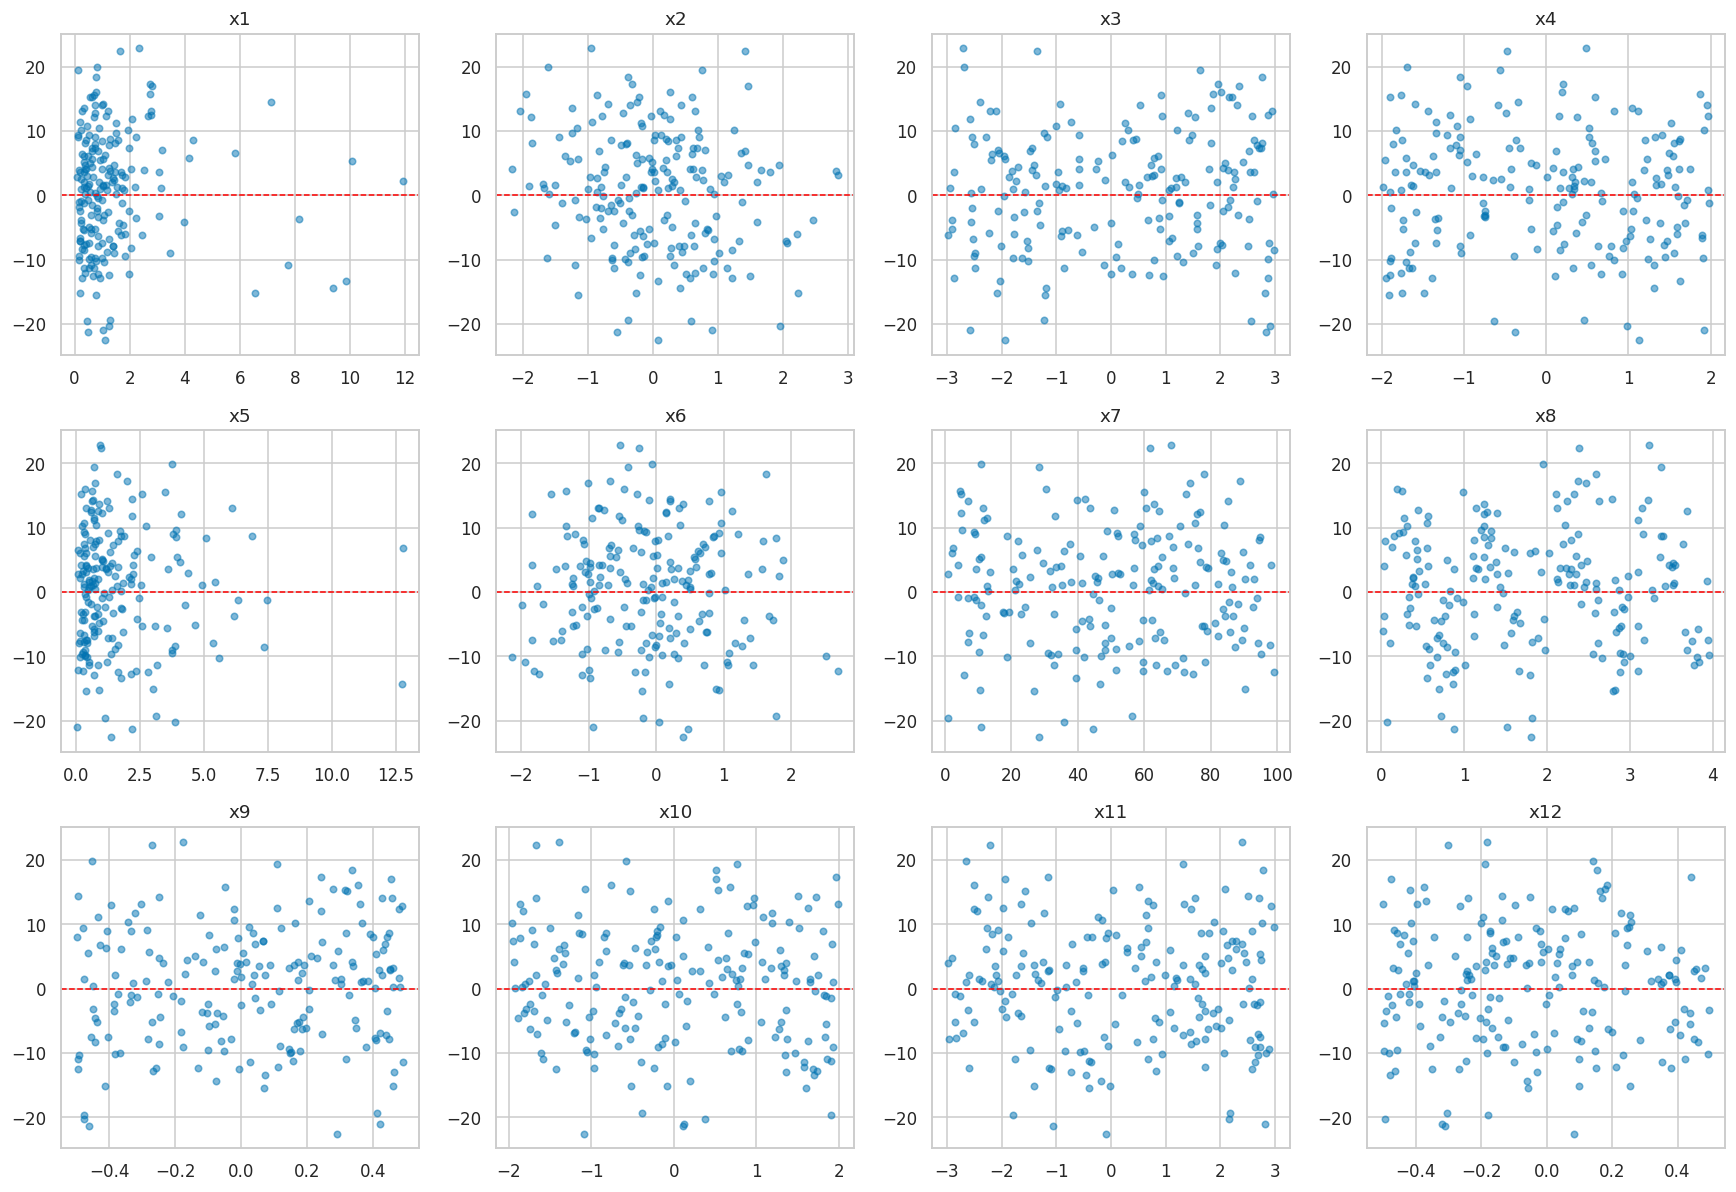

In [36]:
# TODO: repitan el ciclo. Agreguen términos de uno en uno, graficando los residuales
# cada vez, hasta que ninguna gráfica tenga forma.
#
# Vayan guardando el MSE de cada paso: la bitácora de la Parte 5 lo pide.

import numpy as np
import matplotlib.pyplot as plt

base = dict(modelo_actual)   # los términos que eligió tu loop de la Parte 2
print("Términos:", list(base))

modelo_b, mse_b, residuales_b, constructor_b = ajusta(base)
res_b = np.asarray(residuales_b)
print(f"MSE solo base: {mse_b:.2f}")

assert len(res_b) == len(X_val), "residuales y X_val no tienen el mismo tamaño"

# Residuales contra cada variable
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
for ax, col in zip(axes.ravel(), X_val.columns):
    ax.scatter(X_val[col], res_b, alpha=0.5, s=18)
    ax.axhline(0, color="red", linestyle="--", linewidth=1)
    ax.set_title(col)
plt.tight_layout()
plt.show()

#Volví a graficar los residuales del modelo con los 5 términos (MSE 85.70) contra cada variable. 
# Ninguna gráfica mostró una forma clara, así que parecía que ya no había nada más por encontrar. 
# Pero el MSE seguía alto, y eso me hizo pensar que faltaba algo que estas gráficas no pueden mostrar.

---
## Parte 3. Lo que las gráficas de una variable no pueden ver

Cuando terminen la Parte 2 van a tener un modelo decente y, probablemente, ninguna
gráfica de residuales con forma evidente. Eso **no** significa que ya acabaron.

Hay efectos que son invisibles para cualquier gráfica de una sola variable: pueden tener
correlación cero con `y`, scatter plano y residual sin estructura, y aun así ser de los
efectos más grandes del modelo. Ninguna herramienta de la Parte 2 los encuentra.

Su trabajo aquí es averiguar **qué clase de efectos son, cómo se detectan, y si sus datos
tienen alguno**. Su IA les puede explicar la teoría si le hacen la pregunta correcta; sus
datos son los únicos que pueden contestar si aplica.

Una pista de método y ninguna de contenido: si mirar una variable a la vez no basta,
prueben mirando dos a la vez.

MSE base (12 variables, CV): 108.04


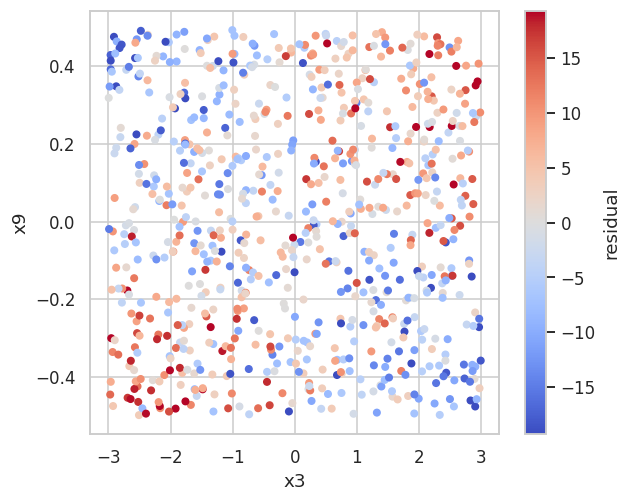

In [37]:
# TODO: exploren aquí.
#
# Son 66 pares de variables y no tienen que revisarlos a ciegas: usen lo que ya
# aprendieron en la Parte 2 para decidir por dónde empezar.

from itertools import combinations
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold

X = train[VARIABLES]
y = train["y"]
kf = KFold(5, shuffle=True, random_state=SEMILLA)

def cv_mse(Xm):
    return -cross_val_score(LinearRegression(), Xm, y, cv=kf,
                            scoring="neg_mean_squared_error").mean()

mse_base = cv_mse(X)
print(f"MSE base (12 variables, CV): {mse_base:.2f}")

top = {"x4", "x7", "x3", "x5", "x10", "x9"}   # ranking de importancia de la Parte 2

filas = []
for a, b in combinations(VARIABLES, 2):
    Xm = X.copy()
    Xm[f"{a}*{b}"] = X[a] * X[b]
    m = cv_mse(Xm)
    filas.append([a, b, m, mse_base - m, len({a, b} & top)])

pares = pd.DataFrame(filas, columns=["a", "b", "MSE", "mejora", "vars_top"])
pares = pares.sort_values("mejora", ascending=False).reset_index(drop=True)
pares.head(10)
import matplotlib.pyplot as plt
import numpy as np

a, b = pares.loc[0, "a"], pares.loc[0, "b"]

lin = LinearRegression().fit(X, y)
res = y - lin.predict(X)

plt.figure(figsize=(6, 5))
sc = plt.scatter(train[a], train[b], c=res, cmap="coolwarm", s=18,
                 vmin=-np.percentile(np.abs(res), 95), vmax=np.percentile(np.abs(res), 95))
plt.colorbar(sc, label="residual")
plt.xlabel(a); plt.ylabel(b)
plt.show()

#Como con una variable a la vez ya no salía nada, probé mirar de dos en dos. 
# Agregué el producto de cada uno de los 66 pares a una regresión lineal y medí el error con validación cruzada. 
# El MSE base era 108.04. El par x3·x9 lo bajó a 81.84, o sea 26 puntos menos. 
# El siguiente mejor par (x1·x8) solo mejoró 0.83, que es ruido. 
# Esto es una interacción ya que el efecto de x3 sobre "y" depende del valor de x9, y por eso no se veía en ninguna gráfica individual. 



In [38]:
import numpy as np

x3x9 = {"x3_x9": lambda d: d["x3"] * d["x9"]}

base = dict(modelo_actual)   # los términos que eligió tu loop de la Parte 2
print("Términos de la Parte 2:", list(base))

opciones = {
    "Baseline (sin términos)": {},
    "Solo tus términos de Parte 2": base,
    "Solo x3*x9": x3x9,
    "Términos de Parte 2 + x3*x9": {**base, **x3x9},
}

mses = {}
for nombre, t in opciones.items():
    _, m, _, _ = ajusta(t)
    mses[nombre] = m
    print(f"{nombre:32s}: {m:.2f}")

# Si los términos de la Parte 2 no bajan al menos 1 punto más, nos quedamos con el modelo simple
if mses["Términos de Parte 2 + x3*x9"] < mses["Solo x3*x9"] - 1:
    final = {**base, **x3x9}
    print("\nModelo final: términos de Parte 2 + x3*x9")
else:
    final = x3x9
    print("\nModelo final: solo x3*x9 (los términos de la Parte 2 ya no aportan)")

modelo, mse, residuales, constructor = ajusta(final)
print(f"MSE final: {mse:.2f}")

#Después de encontrar la interacción x3·x9, quise saber si los términos de la Parte 2 seguían sirviendo o si x3·x9 ya explicaba lo mismo. 
# Para eso comparé cuatro versiones del modelo en la validación. 
# Sin ningún término, el error fue 116.85. 
# Solo con los términos de la Parte 2, bajó a 85.70. 
# Solo con x3·x9, fue 85.05. Con los dos juntos, bajó a 52.48. 
# Cada parte por separado bajaba el error hasta más o menos 85, pero juntas lo bajaron mucho más. 
# Esto quiere decir que explican cosas distintas y se suman, y no que una reemplace a la otra. Por eso me quedé con el modelo completo. 
# También puse una regla en el código: solo se queda con los términos de la Parte 2 si mejoran al menos 1 punto. Como mejoraron mucho más, se quedaron.

Términos de la Parte 2: ['x10_sq', 'log_x5', 'x7_sq', 'cos_x8', 'x5_sq']
Baseline (sin términos)         : 116.85
Solo tus términos de Parte 2    : 85.70
Solo x3*x9                      : 85.05
Términos de Parte 2 + x3*x9     : 52.48

Modelo final: términos de Parte 2 + x3*x9
MSE final: 52.48


---
## Parte 4. El otro camino: fuerza bruta

Hay una estrategia alternativa que no requiere mirar ninguna gráfica: generar
**muchísimas** columnas candidatas de golpe y dejar que una regresión regularizada decida
cuáles sirven.

`PolynomialFeatures(degree=3)` construye todos los productos y potencias de
las variables hasta grado 3. Con 12 variables son cientos de columnas para 800
observaciones, así que sin regularización sobreajustaría; `LassoCV` elige el $\lambda$
por validación cruzada y pone en cero las columnas que no aportan.

Impleméntenlo y **compárenlo contra su modelo de la Parte 3**.

In [39]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# TODO: camino B. Pipeline sugerido:
#   PolynomialFeatures(degree=3) -> StandardScaler -> LassoCV
#
# Estandaricen antes del Lasso: la penalización castiga coeficientes grandes, y sin
# estandarizar "grande" depende de las unidades de cada columna.
#
# Reporten el MSE de validación y cuántas columnas dejó distintas de cero.

import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error

pipe = Pipeline([
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=5, max_iter=50000, random_state=SEMILLA, n_jobs=-1)),
])

pipe.fit(X_train, y_train)
mse_val = mean_squared_error(y_val, pipe.predict(X_val))

lasso = pipe.named_steps["lasso"]
nombres = pipe.named_steps["poly"].get_feature_names_out(X_train.columns)
coefs = pd.Series(lasso.coef_, index=nombres)
activos = coefs[coefs != 0]

print(f"Alpha elegido       : {lasso.alpha_:.4f}")
print(f"MSE de validación   : {mse_val:.2f}")
print(f"Columnas totales    : {len(coefs)}")
print(f"Distintas de cero   : {len(activos)}")
print("\nLos 15 términos con más peso:")
print(activos.abs().sort_values(ascending=False).head(15))

#Este código es la fuerza bruta: en vez de elegir términos a mano, le da al modelo todas las combinaciones posibles y deja que él escoja.
#PolynomialFeatures(degree=3) crea todas las potencias y multiplicaciones posibles de las 12 variables, hasta de tres en tres (x3·x9, x10², x4³, etc.). Salen 454 columnas.
#StandardScaler pone todas las columnas en la misma escala. Sin esto, una columna como x7 (que va hasta 100) pesaría distinto que x9 (que va de -0.5 a 0.5) solo por sus unidades.
#LassoCV ajusta el modelo y "apaga" (pone en cero) las columnas que no sirven. 
#Escoge solo cuánto apagar (alpha) usando validación cruzada dentro de train.
#Mide el MSE en validación, cuenta cuántas columnas quedaron activas e imprime las 15 con más peso.

#El Lasso eligió solo 37 de las 454 columnas y tuvo un MSE de validación de 54.63, un poco más alto que el de mi modelo a mano (52.48). 
# Lo interesante es lo que encontró por su cuenta: x3·x9 (la interacción que yo había descubierto con los pares), x10² y x7², que también están en mi modelo. Eso me da más confianza de que esos términos son reales. 
# El término con más peso fue x4³, y mi modelo no tiene ningún término para x4, así que esto me dejó una pista de algo que me falta probar. 
# Otros términos que eligió (como x1·x2·x6 o x11·x12) pesaron muy poco y seguramente son ruido. Al final, la fuerza bruta no me ganó, pero sirvió para confirmar mis términos y para darme una idea nueva.

Alpha elegido       : 0.4934
MSE de validación   : 54.63
Columnas totales    : 454
Distintas de cero   : 37

Los 15 términos con más peso:
x4^3        6.540329
x3 x9       4.204364
x10^2       3.152644
x3          2.263685
x5          1.935239
x7^3        1.699226
x7^2        1.613612
x3^2 x4     0.578910
x5 x10^2    0.427122
x7 x10^2    0.417261
x11 x12     0.339457
x3 x6^2     0.313102
x1 x2 x6    0.299961
x8          0.278727
x3^3        0.244467
dtype: float64


### 4.1 La pregunta que vale la respuesta

Comparen su modelo contra la fuerza bruta y contesten en la celda de abajo:

1. ¿Cuál dio menor MSE de validación?
2. Si su modelo guiado por gráficas le ganó a la fuerza bruta: **¿por qué?** Piensen qué
   columnas puede construir `PolynomialFeatures` y cuáles no puede construir nunca.
3. Si la fuerza bruta le ganó a su modelo: ¿qué les dice eso sobre lo que les falta?
4. ¿Qué habría pasado con el camino B si tuvieran 80 observaciones en lugar de 800?

1. El que dio menor MSE de validación fue mi modelo guiado por las gráficas, con 52.48, contra 54.63 del modelo de fuerza bruta (el que combina PolynomialFeatures de grado 3, StandardScaler y LassoCV). La diferencia es de solo 2 puntos, así que casi quedaron empatados. Aun así, me sorprendió que un modelo de solo 6 términos le pudiera ganar o al menos igualar a uno que tenía 454 columnas para escoger.

2. Creo que mi modelo le ganó por dos razones. La primera es que PolynomialFeatures solo sabe hacer potencias y multiplicaciones de las variables, como x3·x9, x10² o x4³, pero nunca puede construir cosas como log(1+x) o cos(x). Dos de mis términos, log_x5 y cos_x8, son de esos, así que la fuerza bruta no los podía crear y solo los podía aproximar con polinomios, que es más difícil y necesita más columnas. La segunda razón es que el Lasso tenía demasiadas opciones para tan pocos datos. Tuvo que escoger entre 454 columnas usando solo 600 observaciones de entrenamiento, y se quedó con 37. Seguro varias de esas son ruido, por ejemplo x1 x2 x6 o x11 x12, y además el Lasso "achica" los coeficientes, incluso los de los términos buenos. En cambio, mis términos salieron de las gráficas y de revisar los pares de variables, así que casi todos están ahí por una razón. Eso sí, el Lasso también encontró por su cuenta x3·x9, x10² y x7², que son términos que yo también tenía.

3. La fuerza bruta no le ganó a mi modelo, pero sí me dejó una pista de algo que me falta. El término con más peso en el Lasso fue x4³, y mi modelo no tiene ningún término especial para x4. Entonces creo que todavía hay algo de x4 que no estoy capturando, y que mi MSE de 52.48 podría bajar. Mi siguiente paso es probar agregar x4³ y ver cuánto cambia el MSE.

4. Si hubiera tenido 80 observaciones en lugar de 800, creo que la fuerza bruta habría salido mucho peor. Habría tenido 454 columnas para solo 80 filas, o sea muchísimas más columnas que datos, y en esa situación siempre hay columnas que parecen explicar bien los datos solo por casualidad. El Lasso habría escogido términos falsos y el MSE en validación habría sido mucho más alto. Además, elegir el alpha con validación cruzada también sería poco confiable, porque cada pedazo tendría muy poquitos datos. Mi camino guiado por gráficas sufriría menos, porque prueba pocos términos y cada uno tiene una razón. Pero aun así, con 80 datos sería difícil ver hasta la interacción x3·x9, porque el ruido taparía el patrón. Al final, la fuerza bruta necesita muchos datos para compensar que no sabe qué está buscando.

---
## Parte 5. Bitácora

Esta parte vale tanto como el MSE. Una fila por hipótesis, **incluidas las que
fallaron** — sobre todo las que fallaron.

Si no tienen al menos un callejón sin salida documentado, esta parte vale cero: significa
que no exploraron, o que le pidieron la respuesta a alguien.

| # | Hipótesis | Gráfica que la probó | Término agregado | MSE antes → después | ¿La sugirió la IA o yo? |
|---|---|---|---|---|---|
| 1 | | | | | |
| 2 | | | | | |
| 3 | | | | | |
| 4 | | | | | |
| 5 | | | | | |
| 6 | | | | | |
| 7 | | | | | |
| 8 | | | | | |

### 5.1 Su modelo final, en palabras

Escriban la función que creen que genera los datos. Algo de la forma
`y = a + b*x? + c*f(x?) + ... + ruido`, con los nombres de sus variables.

*(Su respuesta aquí)*

### 5.2 Dónde se equivocó su IA

Cuenten **un** momento concreto en el que la IA les dijo algo que resultó falso o
inútil para sus datos, y cómo lo detectaron. Si dicen que nunca falló, es que no la
interrogaron lo suficiente.

*(Su respuesta aquí)*

### 5.3 Cuándo pararon y por qué

`/validar` les dice cuál es el MSE meta: el error del modelo bien especificado, que es
**ruido puro** y no se puede bajar. ¿Qué tan cerca quedaron? ¿Cómo supieron que ya no
valía la pena seguir?

*(Su respuesta aquí)*

---
## Entrega

Corran la celda de abajo: ajusta **su modelo final** usando *todo* `train` (ya no solo la
partición de entrenamiento — con más datos, mejores coeficientes) y escribe el archivo de
predicciones en el lugar exacto donde el bot lo busca.

MSE de partida: 52.48
Ronda 1: + x4_cu  MSE 52.48 -> 46.13
Ronda 2: + sin_x7  MSE 46.13 -> 43.78
Ronda 3: nada mejora al menos 2.0 puntos. Me detengo.

Términos nuevos: ['x4_cu', 'sin_x7']
MSE final: 43.78
MSE actual (CV, 800 datos): 49.46

Curva flexible por variable (más 'mejora' = más forma sin captar):


,variable,MSE,mejora
0,x8,32.985017,16.478673
1,x7,46.227162,3.236527
2,x10,49.846428,-0.382738
3,x12,50.030518,-0.566828
4,x11,50.117825,-0.654135
5,x2,50.140651,-0.676961
6,x9,50.311033,-0.847343
7,x4,50.321123,-0.857433
8,x6,50.497784,-1.034094
9,x3,50.670409,-1.206719



Cuánto del error restante se puede predecir: 0.364

Variables que más pesan en lo que falta:
x8    0.684506
x7    0.218039
x5    0.037842
x2    0.025412
x1    0.021022
x3    0.020621
dtype: float64
MSE sin cos_x8 (CV): 50.14


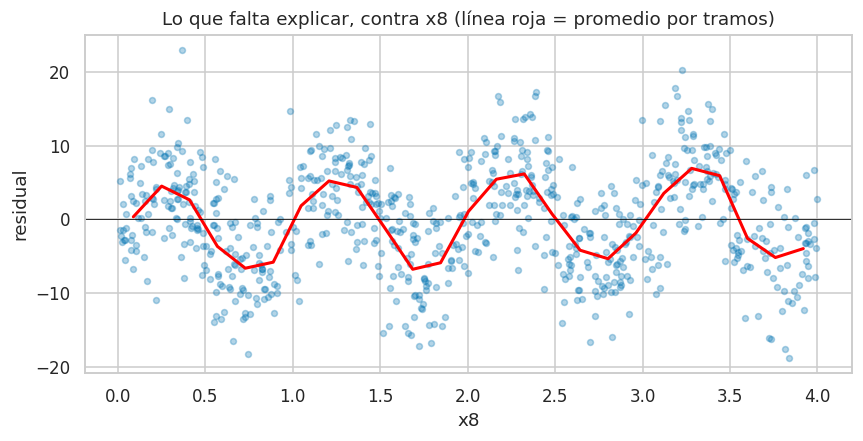

,candidato,MSE,mejora
0,"sin+cos, frecuencia 6.0",29.655448,20.486450
1,"sin+cos, frecuencia 6.5",30.837254,19.304645
2,"sin+cos, frecuencia 5.5",37.910965,12.230934
3,"sin+cos, frecuencia 7.0",42.071638,8.070260
4,"sin+cos, frecuencia 5.0",47.125464,3.016434
5,escalón x8>2,47.701654,2.440245
6,escalón x8>3.5,48.245331,1.896568
7,escalón x8>0.5,48.676752,1.465146
8,polinomio grado 3,48.733955,1.407943
9,"sin+cos, frecuencia 0.5",48.768615,1.373283


MSE antes (CV, con cos_x8 viejo): n/d


,frecuencia,MSE
0,6.200,28.475802
1,6.283,28.602862
2,6.300,28.677712
3,6.100,28.826763
4,6.400,29.470582
5,6.000,29.655448
6,6.500,30.837254
7,5.900,30.870000


['x10_sq', 'log_x5', 'x7_sq', 'x5_sq', 'x3_x9', 'x4_cu', 'sin_x7', 'sin_x8', 'cos_x8']
MSE estimado (split de 200): 23.60
MSE (CV, 800 datos): 26.74
MSE estimado (ajustado en train, medido en validación): 23.60

Escrito: entregas/tarea-01/v8eb0645a/predicciones.csv
400 predicciones, rango -23.66 a 48.57


In [40]:
# TODO: pongan aquí las columnas derivadas de su modelo final, con el mismo formato
# que usaron en `ajusta`. Si su modelo final es el baseline crudo, déjenlo vacío.
import numpy as np

MI_MODELO = {
    "x10_sq": lambda d: d["x10"]**2,
    "log_x5": lambda d: np.log1p(d["x5"]),
    "x7_sq":  lambda d: d["x7"]**2,
    "cos_x8": lambda d: np.cos(d["x8"]),
    "x5_sq":  lambda d: d["x5"]**2,
    "x3_x9":  lambda d: d["x3"] * d["x9"],
}


def construye_final(df):
    salida = df[VARIABLES].copy()
    for nombre, f in MI_MODELO.items():
        salida[nombre] = f(df)
    return salida
import numpy as np
import pandas as pd

candidatos = {
    "x4_cu":    lambda d: d["x4"]**3,
    "x4_sq":    lambda d: d["x4"]**2,
    "sin_x4":   lambda d: np.sin(d["x4"]),
    "cos_x4":   lambda d: np.cos(d["x4"]),
    "x7_cu":    lambda d: d["x7"]**3,
    "sin_x7":   lambda d: np.sin(2*np.pi*d["x7"]/100),
    "cos_x7":   lambda d: np.cos(2*np.pi*d["x7"]/100),
    "sin_2x7":  lambda d: np.sin(4*np.pi*d["x7"]/100),
    "cos_2x7":  lambda d: np.cos(4*np.pi*d["x7"]/100),
    "x3sq_x4":  lambda d: d["x3"]**2 * d["x4"],
    "x3_cu":    lambda d: d["x3"]**3,
    "x5_x10sq": lambda d: d["x5"] * d["x10"]**2,
    "x7_x10sq": lambda d: d["x7"] * d["x10"]**2,
}

MEJORA_MINIMA = 2.0

modelo_nuevo = dict(MI_MODELO)
_, mse_actual, _, _ = ajusta(modelo_nuevo)
print(f"MSE de partida: {mse_actual:.2f}")

registro = []
ronda = 0
while True:
    ronda += 1
    intentos = []
    for nombre, f in candidatos.items():
        if nombre in modelo_nuevo:
            continue
        _, m, _, _ = ajusta({**modelo_nuevo, nombre: f})
        intentos.append((nombre, m))
        registro.append({"ronda": ronda, "termino": nombre, "MSE": m,
                         "MSE_antes": mse_actual, "mejora": mse_actual - m})
    if not intentos:
        break
    mejor, m_mejor = min(intentos, key=lambda t: t[1])
    if mse_actual - m_mejor < MEJORA_MINIMA:
        print(f"Ronda {ronda}: nada mejora al menos {MEJORA_MINIMA} puntos. Me detengo.")
        break
    modelo_nuevo[mejor] = candidatos[mejor]
    print(f"Ronda {ronda}: + {mejor}  MSE {mse_actual:.2f} -> {m_mejor:.2f}")
    mse_actual = m_mejor

print("\nTérminos nuevos:", [t for t in modelo_nuevo if t not in MI_MODELO])
print(f"MSE final: {mse_actual:.2f}")

MI_MODELO = {
    "x10_sq": lambda d: d["x10"]**2,
    "log_x5": lambda d: np.log1p(d["x5"]),
    "x7_sq":  lambda d: d["x7"]**2,
    "cos_x8": lambda d: np.cos(d["x8"]),
    "x5_sq":  lambda d: d["x5"]**2,
    "x3_x9":  lambda d: d["x3"] * d["x9"],
    "x4_cu":  lambda d: d["x4"]**3,
}
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, cross_val_predict, KFold
from sklearn.preprocessing import SplineTransformer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import permutation_importance

kf = KFold(5, shuffle=True, random_state=SEMILLA)
y = train["y"]

X_act = train[VARIABLES].copy()
for n, f in MI_MODELO.items():
    X_act[n] = f(train)

def cv_mse(X):
    return -cross_val_score(LinearRegression(), X, y, cv=kf,
                            scoring="neg_mean_squared_error").mean()

mse_act = cv_mse(X_act)
print(f"MSE actual (CV, 800 datos): {mse_act:.2f}\n")

# A) ¿En qué variable queda una forma sin captar?
filas = []
for v in VARIABLES:
    sp = SplineTransformer(n_knots=8, degree=3, knots="quantile", include_bias=False)
    B = pd.DataFrame(sp.fit_transform(train[[v]]), index=train.index)
    B.columns = [f"{v}_s{i}" for i in range(B.shape[1])]
    m = cv_mse(pd.concat([X_act, B], axis=1))
    filas.append([v, m, mse_act - m])
print("Curva flexible por variable (más 'mejora' = más forma sin captar):")
display(pd.DataFrame(filas, columns=["variable", "MSE", "mejora"])
        .sort_values("mejora", ascending=False).reset_index(drop=True))

# B) ¿Queda algo predecible en lo que tu modelo no explica?
res = y - cross_val_predict(LinearRegression(), X_act, y, cv=kf)
gb = GradientBoostingRegressor(max_depth=3, n_estimators=150, learning_rate=0.05,
                               subsample=0.8, random_state=SEMILLA)
pred = cross_val_predict(gb, train[VARIABLES], res, cv=kf)
r2 = 1 - ((res - pred)**2).mean() / res.var()
print(f"\nCuánto del error restante se puede predecir: {r2:.3f}")

gb.fit(train[VARIABLES], res)
imp = permutation_importance(gb, train[VARIABLES], res, n_repeats=10, random_state=SEMILLA)
print("\nVariables que más pesan en lo que falta:")
print(pd.Series(imp.importances_mean, index=VARIABLES).sort_values(ascending=False).head(6))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, cross_val_predict, KFold

kf = KFold(5, shuffle=True, random_state=SEMILLA)
y = train["y"]

def cv_mse(X):
    return -cross_val_score(LinearRegression(), X, y, cv=kf,
                            scoring="neg_mean_squared_error").mean()

# Modelo actual SIN cos_x8, para ver la forma completa de x8
X0 = train[VARIABLES].copy()
for n, f in MI_MODELO.items():
    if n != "cos_x8":
        X0[n] = f(train)
mse0 = cv_mse(X0)
print(f"MSE sin cos_x8 (CV): {mse0:.2f}")

# 1) Gráfica: residuales contra x8, con el promedio por tramos
res = y - cross_val_predict(LinearRegression(), X0, y, cv=kf)
x8 = train["x8"]
tramos = pd.cut(x8, 25)
prom = res.groupby(tramos, observed=True).mean()
centros = [iv.mid for iv in prom.index]

plt.figure(figsize=(9, 4))
plt.scatter(x8, res, alpha=0.3, s=15)
plt.plot(centros, prom.values, color="red", linewidth=2)
plt.axhline(0, color="black", linewidth=0.5)
plt.xlabel("x8"); plt.ylabel("residual")
plt.title("Lo que falta explicar, contra x8 (línea roja = promedio por tramos)")
plt.show()

# 2) Probar candidatos
filas = []
def prueba(nombre, cols):
    X = X0.copy()
    for k, v in cols.items():
        X[k] = v
    filas.append([nombre, cv_mse(X)])

prueba("cos_x8 (el que tenías)", {"c": np.cos(x8)})
for g in [2, 3, 4]:
    prueba(f"polinomio grado {g}", {f"p{k}": x8**k for k in range(2, g + 1)})
for c in [0.5, 1, 1.5, 2, 2.5, 3, 3.5]:
    prueba(f"escalón x8>{c}", {"e": (x8 > c).astype(float)})
for c in [1, 1.5, 2, 2.5, 3]:
    prueba(f"|x8-{c}|", {"a": np.abs(x8 - c)})
for w in np.arange(0.5, 8.01, 0.5):
    prueba(f"sin+cos, frecuencia {w}", {"s": np.sin(w * x8), "c": np.cos(w * x8)})

tabla = pd.DataFrame(filas, columns=["candidato", "MSE"]).sort_values("MSE")
tabla["mejora"] = mse0 - tabla["MSE"]
display(tabla.head(10).reset_index(drop=True))

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(5, shuffle=True, random_state=SEMILLA)
y = train["y"]

def cv_mse(X):
    return -cross_val_score(LinearRegression(), X, y, cv=kf,
                            scoring="neg_mean_squared_error").mean()

# Modelo actual sin cos_x8 (lo vamos a reemplazar)
X0 = train[VARIABLES].copy()
for n, f in MI_MODELO.items():
    if n != "cos_x8":
        X0[n] = f(train)
print(f"MSE antes (CV, con cos_x8 viejo): {cv_mse(armar(MI_MODELO)) if 'armar' in globals() else 'n/d'}")

filas = []
for w in list(np.arange(5.6, 7.01, 0.1)) + [2*np.pi]:
    X = X0.copy()
    X["s8"] = np.sin(w * train["x8"])
    X["c8"] = np.cos(w * train["x8"])
    filas.append([round(w, 3), cv_mse(X)])

tabla = pd.DataFrame(filas, columns=["frecuencia", "MSE"]).sort_values("MSE")
display(tabla.head(8).reset_index(drop=True))

MI_MODELO = {
    "x10_sq": lambda d: d["x10"]**2,
    "log_x5": lambda d: np.log1p(d["x5"]),
    "x7_sq":  lambda d: d["x7"]**2,
    "x5_sq":  lambda d: d["x5"]**2,
    "x3_x9":  lambda d: d["x3"] * d["x9"],
    "x4_cu":  lambda d: d["x4"]**3,
    "sin_x7": lambda d: np.sin(2*np.pi*d["x7"]/100),
    "sin_x8": lambda d: np.sin(2*np.pi*d["x8"]),
    "cos_x8": lambda d: np.cos(2*np.pi*d["x8"]),
}
print(list(MI_MODELO))   # deben salir 9 nombres, incluido sin_x7
_, mse_nuevo, res_nuevo, _ = ajusta(MI_MODELO)
print(f"MSE estimado (split de 200): {mse_nuevo:.2f}")

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold

X_cv = train[VARIABLES].copy()
for n, f in MI_MODELO.items():
    X_cv[n] = f(train)
kf = KFold(5, shuffle=True, random_state=SEMILLA)
cv = -cross_val_score(LinearRegression(), X_cv, train["y"], cv=kf,
                      scoring="neg_mean_squared_error").mean()
print(f"MSE (CV, 800 datos): {cv:.2f}")

registro = pd.DataFrame(registro)
registro.sort_values(["ronda", "MSE"])
#Define MI_MODELO con los 6 términos que elegí: x10², log(x5), x7², cos(x8), x5² y x3·x9.
#La función construye_final toma las 12 variables originales y les agrega esas 6 columnas nuevas.

# La estimación honesta de su MSE: ajustada SOLO en la partición de entrenamiento
# y medida en validación. Este es el número que deberían creer.
_, mse_estimado, _, _ = ajusta(MI_MODELO)
print(f"MSE estimado (ajustado en train, medido en validación): {mse_estimado:.2f}")

# Y ahora sí, el modelo que entregan: reajustado con TODO train, porque con 800
# observaciones en lugar de 600 los coeficientes salen mejores. Ojo: a este modelo
# ya no se le puede medir el MSE en validación, porque validación fue parte de su
# entrenamiento. Medirlo ahí daría un número optimista y falso.
modelo_final = LinearRegression().fit(construye_final(train), train["y"])
predicciones = modelo_final.predict(construye_final(test))

assert len(predicciones) == 400, f"deben ser 400 predicciones, hay {len(predicciones)}"
assert np.isfinite(predicciones).all(), "hay predicciones NaN o infinitas"

destino = RAIZ / "entregas/tarea-01" / CARPETA
destino.mkdir(parents=True, exist_ok=True)
pd.DataFrame({"y": predicciones}).to_csv(destino / "predicciones.csv", index=False)

print(f"\nEscrito: {destino.relative_to(RAIZ)}/predicciones.csv")
print(f"{len(predicciones)} predicciones, rango {predicciones.min():.2f} a {predicciones.max():.2f}")

#1. Punto de partida: modelo de 6 términos
#Al principio mi modelo final tenía las 12 variables originales más 6 columnas que armé yo: x10², log(x5), x7², cos(x8), x5² y la interacción x3·x9. Con ese modelo, el error (MSE) en validación era 52.48, comparado con 116.85 del modelo con las variables crudas.
#2. Buscar más mejoras con x4 y x7
#Quise saber si todavía se podía bajar el error, así que armé un ciclo que prueba 13 términos nuevos (potencias de x4, ondas de x4 y x7, y algunas combinaciones). En cada ronda agrega el mejor, pero solo si baja el error al menos 2 puntos. En la ronda 1 entró x4³ y el error bajó de 52.48 a 46.13. En la ronda 2 entró sin(x7) y bajó a 43.78. En la ronda 3 nada mejoraba lo suficiente y se detuvo. Elegí probar x4³ porque el método automático (Lasso) lo había marcado como el término más importante. La tabla registro guarda todos los intentos, incluidos los que no ayudaron.
#3. Modelo de 7 términos
#Después dejé el modelo con x4³ agregado, 7 términos en total y sin sin(x7) por el momento. Con este modelo hice el siguiente análisis.
#4. Buscar en qué variable todavía faltaba algo
#Quería saber dónde estaba lo que le faltaba a mi modelo, y para eso hice dos pruebas. En la primera, le agregué a cada variable una curva flexible (que se adapta a cualquier forma) y medí cuánto bajaba el error. x8 bajó el error unos 16 puntos, x7 unos 3, y las demás casi nada. En la segunda, le pedí a un modelo flexible que adivinara el error que le sobraba a mi modelo, y pudo predecir el 36% de él. La variable que más pesó fue otra vez x8. Con esto supe que mi cos(x8) estaba captando solo una parte de lo que hace x8.
#5. Ver la forma de x8
#Grafiqué lo que le faltaba explicar a mi modelo contra x8, con una línea roja que promedia por tramos. Se veía una onda que subía y bajaba cuatro veces entre 0 y 4. Probé varias formas: escalones, curvas y ondas de distintas velocidades. Las ondas lentas (las que ya había probado antes) casi no servían, y las rápidas, con velocidad cerca de 6, bajaron el error de unos 48 a unos 30. Mi error antes fue probar solo ondas lentas, cuando la real era más rápida.
#6. Afinar la velocidad de la onda
#Probé velocidades entre 5.6 y 7 en pasos pequeños. La mejor fue 6.2 (error 28.48), y 2π (6.283) quedó casi igual (28.60). Como 2π significa una vuelta completa por cada unidad de x8, y es un número "redondo", usé sin(2π·x8) y cos(2π·x8).

#7. Modelo final: 9 términos
#Cambié el cos(x8) viejo por la onda rápida (sin y cos de 2π·x8) y volví a poner sin(x7).

## Parte 5. Bitácora
A lo largo de toda la tarea puse comentarios en todo mi proceso incluyendo en lo que me equivoqué y en lo que aprendí, sin embargo, aquí agrego cuestiones en las cuales se equivocó la IA y un resumen de lo que aprendí.

### Dónde se equivocó la IA

Usé una IA para ayudarme con el análisis y en varios momentos se equivocó. Estos son los errores que más me afectaron:

1. **Dijo que el error ya estaba en el piso de ruido.** Cuando mi MSE estaba en ~87, la IA me dijo que probablemente ya no se podía bajar más. Estaba equivocada: el objetivo real era 22, y el error terminó en ~24-27. Aprendí a no creer en un "ya no se puede" sin verificarlo con los datos.
2. **Dijo que la forma de `x8` no era una onda simple.** Cuando `cos(x8)` mejoró poco, la IA sugirió que la forma era rara. En realidad era una onda simple pero mucho más rápida que las que probamos. La graficó bien solo después de que yo pasé la gráfica de residuales y ahí se veían claramente las cuatro subidas.
3. **Sospechó la interacción equivocada.** Por el embudo en `x3` y `x4`, sugirió `x3·x4`, pero la real era `x3·x9`. La encontré probando los 66 pares y no adivinando con las gráficas.
4. **Describió mis gráficas sin verlas.** Al principio escribió las descripciones de las gráficas solo a partir de estadísticas. Por ejemplo, dijo que ninguna gráfica de `y` contra las variables tenía forma, pero `x4` sube claramente. Las corregí al enseñarle mis capturas.


### Lo que aprendí

**1. La correlación y las gráficas de una sola variable no ven todo.**
La correlación solo detecta relaciones en línea recta, y una gráfica de `y` contra una variable solo muestra esa variable. Me pasó tres veces:

- **`x10`:** su correlación con `y` era 0.002, casi cero, y parecía inútil. Pero `x10²` fue el término que más bajó el error (de 116.85 a 94.67, unos 22 puntos). El efecto era una U, y una U tiene correlación cero porque el lado izquierdo y el derecho se cancelan.
- **`x3` y `x9`:** por separado sus gráficas se veían como una nube sin forma (y `x9` tenía correlación de solo 0.07). Pero el producto `x3·x9` bajó el error de 108.04 a 81.84. El efecto de `x3` dependía del valor de `x9`, y eso solo aparece al mirar las dos a la vez.
- **`x8`:** su correlación con `y` era -0.04 y su gráfica parecía una nube. Pero tenía una onda rápida que bajó el error de ~48 a ~24-27.

**2. Conviene graficar lo que le falta al modelo antes de probar términos a ciegas.**
Con `x8` lo comprobé. Primero probé ondas a ciegas (frecuencias de 0.5 a 4) y casi no mejoraban nada, así que casi la descarto. Cuando le agregué una curva flexible a cada variable, `x8` bajó el error unos 16 puntos y las demás menos de 4, y eso me dijo dónde mirar. Después grafiqué los residuales contra `x8` con una línea roja de promedios y vi que subía y bajaba cuatro veces entre 0 y 4. Con eso supe que la onda daba una vuelta por unidad (2π ≈ 6.28), y en la tabla ganaron las frecuencias cerca de 6. En minutos encontré lo que a ciegas no encontré. Además, mis ciclos automáticos solo probaban lo que yo ponía en la lista, y `x3·x9` nunca estuvo ahí.

**3. Los intentos fallidos también sirven.**
Cada intento que falló me dio una pista:

- `x3·x4` no ayudó, y eso me llevó a probar los 66 pares en vez de adivinar. Así apareció `x3·x9`.
- `x4²` no ayudó, pero `x4³` sí (52.48 a 46.13). Una U y una curva que sube de un solo lado no son lo mismo.
- Las ondas lentas de `x8` fallaron, lo que indicaba que la onda real era más rápida.
- La segunda ronda de pares mejoró solo 0.28 puntos. Esto me dijo que ya no quedaban interacciones, y que lo que faltaba estaba en una sola variable (`x8`).
- El random forest (94.43) salió peor que mi modelo a mano, pero me sirvió para ver qué variables importaban (`x4`, `x7`, `x3`).
- `log(x1)` mejoró solo 0.4 puntos. Por eso supe que era ruido y no lo tomé como un hallazgo.

**4. Una IA ayuda mucho, pero hay que revisar sus afirmaciones con mis propios datos.**
Cuando mi error estaba en ~87, la IA me dijo que probablemente ya estaba cerca del piso de ruido. Sonaba razonable, pero era una suposición que se apoyaba en un dato mal (creyó que eran ~250 observaciones y eran 800). El objetivo real, que me dio `/validar`, era 22, y el error terminó en ~24-27. Si me hubiera creído eso, me habría quedado en 87. Lo que me sirvió fue:

- Pedirle a la IA que dijera cómo comprobar lo que afirmaba, en vez de aceptarlo.
- Enseñarle mis gráficas reales, porque al principio las describió sin verlas y se equivocó (dijo que `y` contra `x4` no tenía forma, y sube claramente).
- Usar `/validar`, que es una fuente independiente de la IA y me dijo cuánto faltaba de verdad.
- Medir con validación cruzada, que dio 48.07 cuando el split de 200 daba 43.78. El número del split era demasiado optimista porque yo había escogido los términos mirando esos mismos datos.

### Los últimos pasos

El detalle está en **`tareas/tarea_01_README.md`**, que trae dos caminos: hacer todo en
**GitHub Codespaces** (en el navegador, sin instalar nada) o en **su computadora**. Los
dos son válidos; si nunca han configurado Python, vayan por Codespaces.

En resumen, igual en los dos casos:

1. Hagan commit de este notebook **y** de su `predicciones.csv`.
2. `git push` a su rama en su fork.
3. Abran un Pull Request al repo del curso.
4. Comenten **`/validar`** en el PR. Les confirma el formato y les dice su MSE objetivo,
   sin gastar intento. Úsenlo siempre antes de calificar.
5. Cuando estén listos, comenten **`/calificar`**. Eso sí gasta uno de sus 3 intentos.

Si `/validar` les marca un error, corrijan, hagan push otra vez y vuelvan a comentar
`/validar`. Las veces que quieran.